In [1]:
import pandas as pd

In [26]:
import os
output_dir = "/lustre/groups/ml01/workspace/ot_perturbation/figures/pbmc_new_cytokine/benchmark"


In [2]:
df = pd.read_csv("/lustre/groups/ml01/workspace/ot_perturbation/data/pbmc/results/allocation/metrics_new_cytokine.csv", index_col=None)

/tmp/ipykernel_394078/3858461052.py:1: DtypeWarning: Columns (1,128,129,171) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/lustre/groups/ml01/workspace/ot_perturbation/data/pbmc/results/allocation/metrics_new_cytokine.csv", index_col=None)


In [3]:
df.head()

,Unnamed: 0.1,Unnamed: 0,mean_decoded_r_sq_per_cell_type,mean_e_distance_per_cell_type,mean_mmd_per_cell_type,mean_sdiv_10_per_cell_type,mean_sdiv_100_per_cell_type,mean_deg_r_sq_per_cell_type,mean_deg_e_distance_per_cell_type,mean_deg_mmd_per_cell_type,...,deg_e_distance_pDC,deg_mmd_pDC,deg_div_10_pDC,deg_div_100_pDC,donor_cytokine,donor,cytokine,method,donor_cytokine_split-idx,split-idx
0,0,Donor4_C5a,0.955791,11.660839,0.008871,90.671855,12.128944,0.873296,17.662023,0.040608,...,NaN,NaN,NaN,NaN,Donor4_C5a,Donor4,C5a,cf,NaN,NaN
1,1,Donor7_OX40L,0.922924,35.460599,0.013862,111.972876,25.847652,0.765109,35.802167,0.046710,...,NaN,NaN,NaN,NaN,Donor7_OX40L,Donor7,OX40L,cf,NaN,NaN
2,2,Donor10_C5a,0.948272,16.919249,0.010235,97.359693,15.502340,0.816124,25.159851,0.041936,...,NaN,NaN,NaN,NaN,Donor10_C5a,Donor10,C5a,cf,NaN,NaN
3,3,Donor11_4-1BBL,0.931346,22.054480,0.014290,102.952084,17.665734,0.813616,24.228663,0.046342,...,NaN,NaN,NaN,NaN,Donor11_4-1BBL,Donor11,4-1BBL,cf,NaN,NaN
4,4,Donor6_OSM,0.955859,13.854135,0.007579,96.074269,13.403070,0.880971,18.501366,0.038873,...,NaN,NaN,NaN,NaN,Donor6_OSM,Donor6,OSM,cf,NaN,NaN


In [4]:
cols_to_keep = [col for col in df.columns if "deg_decoded_r_squared" in col] + ["num_donors_in_train"]

In [5]:
df_cf = df[df["method"]=="cf"]
df_m1 = df[df["method"]=="m1"]


In [6]:
for col in [col for col in df.columns if "deg_decoded_r_squared" in col]:
    print(col, df_cf[~df_cf[col].isnull()]["donor"].nunique())

deg_decoded_r_squared_B Naive 12
deg_decoded_r_squared_CD4 Memory 12
deg_decoded_r_squared_CD14 Mono 12
deg_decoded_r_squared_CD16 Mono 11
deg_decoded_r_squared_CD8 Memory 12
deg_decoded_r_squared_CD56-bright NK 12
deg_decoded_r_squared_CD4 Naive 12
deg_decoded_r_squared_CD8 Naive 12
deg_decoded_r_squared_B Intermediate/Memory 12
deg_decoded_r_squared_CD56-dim NK 12
deg_decoded_r_squared_cDC 12
deg_decoded_r_squared_Treg 12
deg_decoded_r_squared_NKT 10
deg_decoded_r_squared_MAIT 12
deg_decoded_r_squared_pDC 1


In [7]:
cols_to_keep.remove("deg_decoded_r_squared_pDC")

In [8]:
df_cf = df_cf[cols_to_keep]
df_m1 = df_m1[cols_to_keep]

In [9]:
df_cf = df_cf.groupby(["num_donors_in_train"]).mean()

In [10]:
df_m1 = df_m1.groupby(["num_donors_in_train"]).mean()

In [11]:
df_diff = df_cf.sub(df_m1)

In [15]:
y_axis_labels = [el.split("_")[-1] for el in df_diff.columns]

In [14]:
y_axis_labels

['B Naive',
 'CD4 Memory',
 'CD14 Mono',
 'CD16 Mono',
 'CD8 Memory',
 'CD56-bright NK',
 'CD4 Naive',
 'CD8 Naive',
 'B Intermediate/Memory',
 'CD56-dim NK',
 'cDC',
 'Treg',
 'NKT',
 'MAIT']

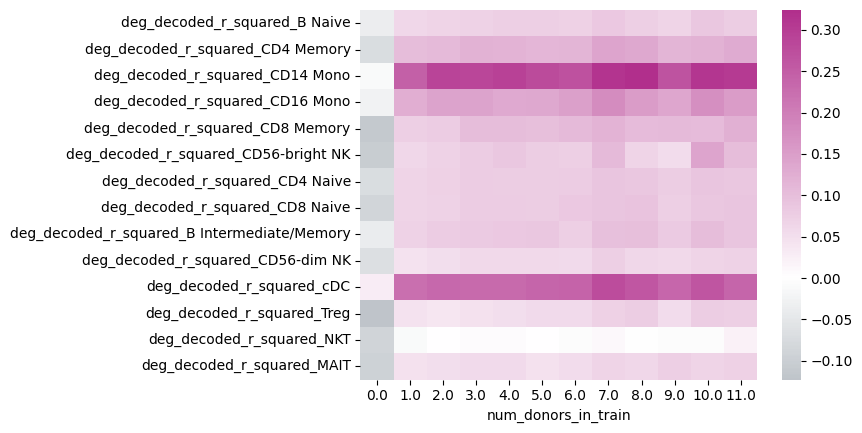

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Define your custom diverging colormap
cmap = LinearSegmentedColormap.from_list("custom_div", ["#566573", "white", "#B12F8C"])

# Plot heatmap with custom colormap
sns.heatmap(df_diff.T, cmap=cmap, center=0)

plt.show()

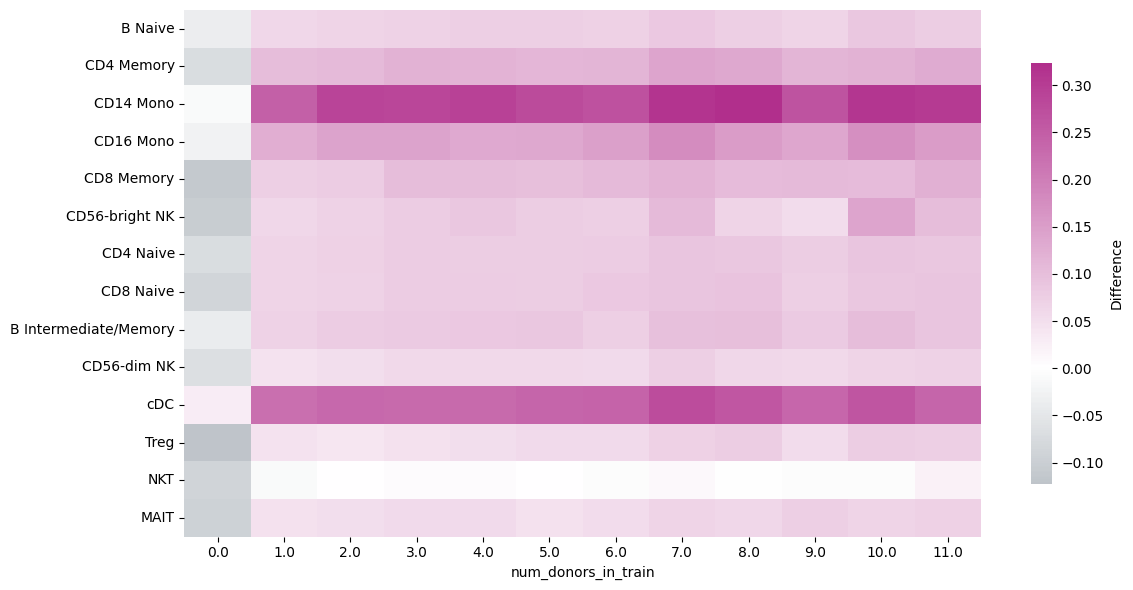

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Define custom diverging colormap
cmap = LinearSegmentedColormap.from_list(
    "custom_div", ["#566573", "white", "#B12F8C"]
)

# Extract custom y-axis labels
y_axis_labels = [el.split("_")[-1] for el in df_diff.columns]

# Set wider figure size
plt.figure(figsize=(12, 6))

# Plot heatmap
sns.heatmap(
    df_diff.T,
    cmap=cmap,
    center=0,
    yticklabels=y_axis_labels,
    cbar_kws={"shrink": 0.8, "label": "Difference"}
)

plt.tight_layout()

plt.savefig(os.path.join(output_dir, "deg_per_cell_type_diff.pdf"), format="pdf")
plt.show()


<Figure size 640x480 with 0 Axes>